# Cafe Sales Data Cleaning & Visualization


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("cleaned_cafe_sales.csv")

print(df.shape)
df.head()


(10000, 10)


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date,is_total_spent_valid,is_total_spent_valid_after_fix
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08,True,True
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16,True,True
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19,False,True
3,TXN_7034554,Salad,2.0,5.0,10.0,unknown,unknown,2023-04-27,True,True
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11,True,True


## Data Cleaning Summary

### Issues found in raw dataset
- Column names had spaces and mixed casing.
- Many missing values across Item, Quantity, Price Per Unit, Total Spent, Payment Method, Location, and Transaction Date.
- Placeholder/invalid values such as **UNKNOWN** and **ERROR** appeared in categorical/numeric fields.
- Numeric fields were stored as text.
- Business rule violations existed where **Total Spent ≠ Quantity × Price Per Unit**.
- Transaction dates needed conversion/validation.
- Duplicate checks were required.

### Cleaning decisions and assumptions
- Standardized column names to lowercase with underscores.
- Converted placeholder values (UNKNOWN/ERROR/blank) to missing values (NaN).
- Filled categorical missing values:
  - **item** filled with mode (most frequent value).
  - **payment_method** and **location** filled with `"unknown"` (no guessing).
- Converted numeric columns using coercion and filled missing values with median.
- Validated **Total Spent = Quantity × Price Per Unit** and corrected inconsistent rows while keeping validation flags.
- Converted transaction_date to datetime format and handled missing/invalid dates.
- Checked duplicates for full rows and transaction_id.


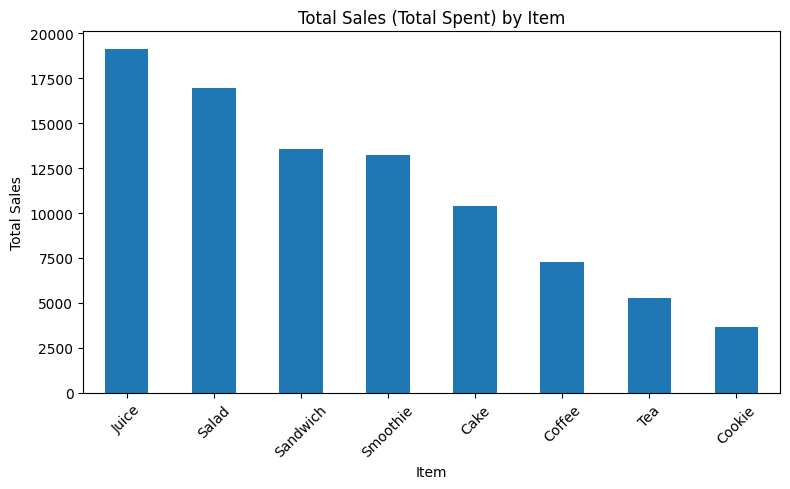

In [2]:
# Bar Chart: Total sales by item
item_sales = df.groupby("item")["total_spent"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
item_sales.plot(kind="bar")
plt.title("Total Sales (Total Spent) by Item")
plt.xlabel("Item")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


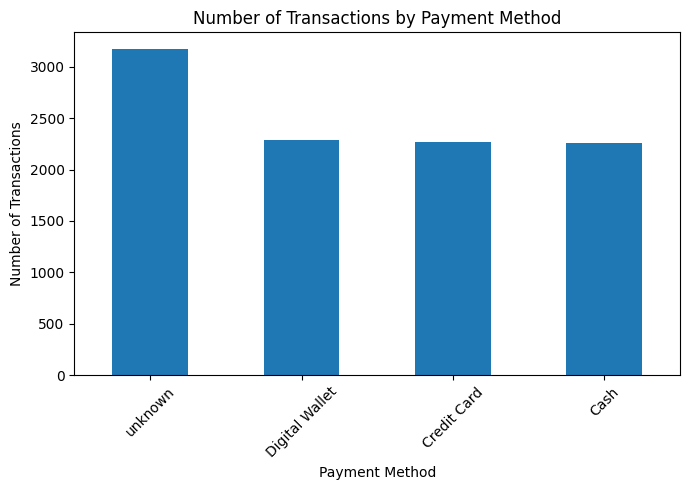

In [3]:
# Bar Chart: Number of transactions by payment method
pm_counts = df["payment_method"].value_counts()

plt.figure(figsize=(7, 5))
pm_counts.plot(kind="bar")
plt.title("Number of Transactions by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


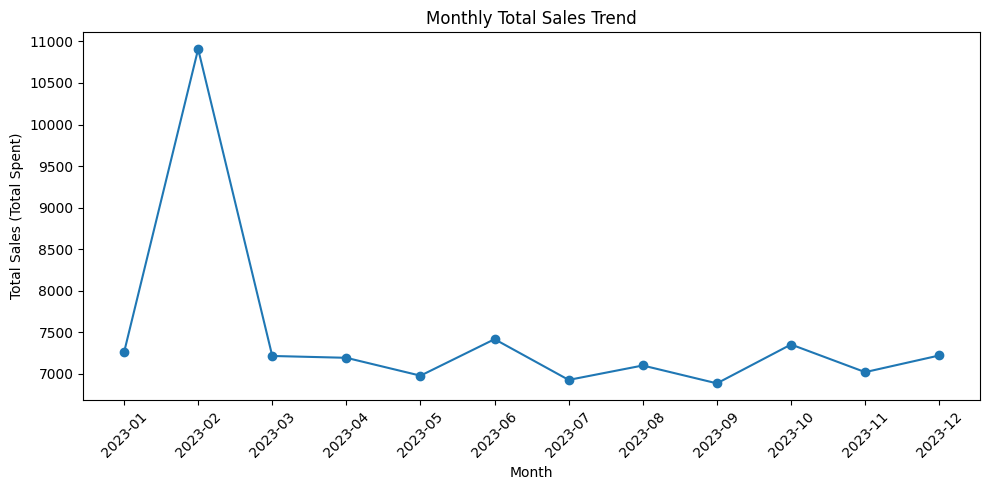

In [4]:
# Line Chart: Monthly total sales trend
df["transaction_date"] = pd.to_datetime(df["transaction_date"], errors="coerce")
df["month"] = df["transaction_date"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("month")["total_spent"].sum().sort_index()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.title("Monthly Total Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales (Total Spent)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


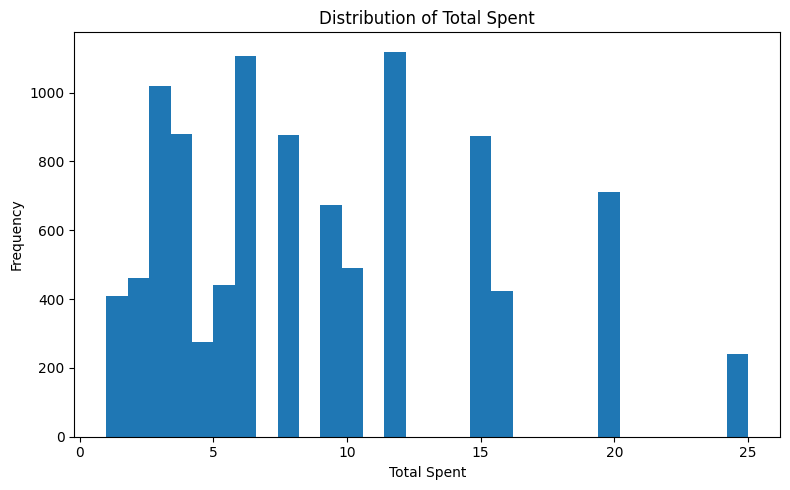

In [5]:
# Histogram: Distribution of total_spent
plt.figure(figsize=(8, 5))
plt.hist(df["total_spent"], bins=30)
plt.title("Distribution of Total Spent")
plt.xlabel("Total Spent")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


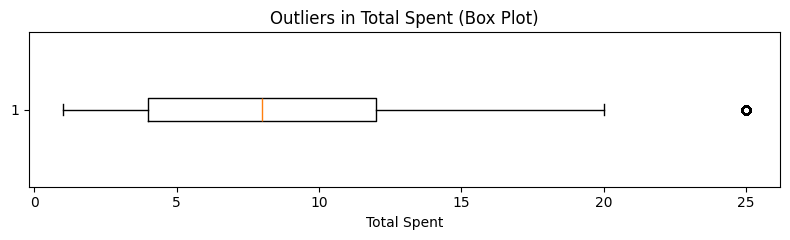

In [6]:
# Box Plot: Outliers in total_spent
plt.figure(figsize=(8, 2.5))
plt.boxplot(df["total_spent"], vert=False)
plt.title("Outliers in Total Spent (Box Plot)")
plt.xlabel("Total Spent")
plt.tight_layout()
plt.show()


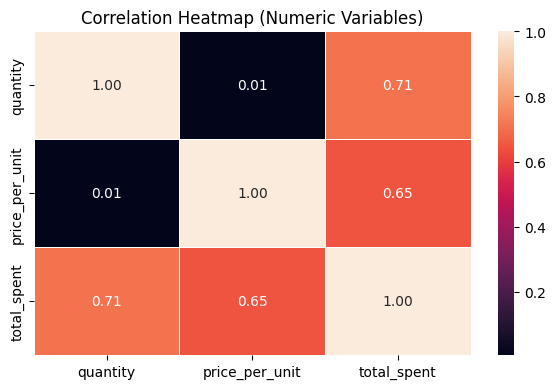

In [7]:
# Heatmap: Correlations between numeric variables
numeric_df = df[["quantity", "price_per_unit", "total_spent"]]

plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap (Numeric Variables)")
plt.tight_layout()
plt.show()


## Insights from Visualizations

- **Top items by revenue:** Juice and Salad generate the highest total sales, followed by Sandwich and Smoothie. This suggests these items are the strongest revenue drivers.
- **Payment method behavior:** A large portion of transactions are labeled **"unknown"**, which reflects missing payment method data in the raw dataset. Among known methods, Digital Wallet, Credit Card, and Cash are fairly balanced.
- **Sales trend over time:** Monthly sales remain relatively steady across the year with some month-to-month variation, indicating stable demand with occasional peaks.
- **Spending distribution:** The histogram shows most purchases fall into a common mid-range spending band, with fewer high-spend purchases.
- **Outliers:** The box plot confirms some unusually high total_spent transactions compared to typical purchases.
- **Correlations (bonus):** Total spent correlates strongly with quantity and price per unit, which is expected since total spent depends on both.
